In [9]:
import sys
import os
from functools import partial

sys.path.append(os.path.abspath(".."))

from src.backtest import momentum_low_vol_score, run_factor_backtest
from src.data_loader import load_prices
from src.experiment import parameter_sensitivity_analysis
from src.visualization import plot_parameter_sensitivity


In [10]:
prices = load_prices()


In [11]:
def run_momentum_low_vol_factor_backtest(
    prices,
    momentum_weight,
    low_vol_weight,
):
    return run_factor_backtest(
        prices,
        score_function=partial(
            momentum_low_vol_score,
            momentum_weight=momentum_weight,
            low_vol_weight=low_vol_weight,
            lookback=252,
            vol_window=252,
        ),
        top_n=5,
        strategy_name="Momentum + Low Vol",
    )


# Run parameter sensitivity analysis
results, portfolios = parameter_sensitivity_analysis(
    prices=prices,
    backtest_function=run_momentum_low_vol_factor_backtest,
    factor_1_name="Momentum",
    factor_2_name="Low Vol",
    factor_1_weight_name="momentum_weight",
    factor_2_weight_name="low_vol_weight",
)

results


,Momentum Weight,Low Vol Weight,CAGR,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
0,0.0,1.0,0.068442,0.074320,0.134419,0.552895,-0.149189
1,0.1,0.9,0.073385,0.079714,0.140640,0.566797,-0.174670
2,0.2,0.8,0.084596,0.090266,0.142498,0.633451,-0.159261
3,0.3,0.7,0.087220,0.093750,0.150527,0.622810,-0.189550
4,0.4,0.6,0.112739,0.118940,0.164344,0.723724,-0.148900
5,0.5,0.5,0.139358,0.145261,0.180922,0.802892,-0.134916
6,0.6,0.4,0.115741,0.126439,0.191973,0.658630,-0.311425
7,0.7,0.3,0.178337,0.181928,0.196995,0.923515,-0.229050
8,0.8,0.2,0.199179,0.198598,0.192842,1.029851,-0.224568
9,0.9,0.1,0.173850,0.178375,0.198077,0.900530,-0.262405


In [12]:
# Sort results by CAGR
results.sort_values(
    "CAGR",
    ascending=False
)

,Momentum Weight,Low Vol Weight,CAGR,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
10,1.0,0.0,0.230520,0.225387,0.198403,1.136003,-0.177543
8,0.8,0.2,0.199179,0.198598,0.192842,1.029851,-0.224568
7,0.7,0.3,0.178337,0.181928,0.196995,0.923515,-0.229050
9,0.9,0.1,0.173850,0.178375,0.198077,0.900530,-0.262405
5,0.5,0.5,0.139358,0.145261,0.180922,0.802892,-0.134916
6,0.6,0.4,0.115741,0.126439,0.191973,0.658630,-0.311425
4,0.4,0.6,0.112739,0.118940,0.164344,0.723724,-0.148900
3,0.3,0.7,0.087220,0.093750,0.150527,0.622810,-0.189550
2,0.2,0.8,0.084596,0.090266,0.142498,0.633451,-0.159261
1,0.1,0.9,0.073385,0.079714,0.140640,0.566797,-0.174670


In [13]:
# Sort results by Sharpe Ratio
results.sort_values(
    "Sharpe Ratio",
    ascending=False
)

,Momentum Weight,Low Vol Weight,CAGR,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
10,1.0,0.0,0.230520,0.225387,0.198403,1.136003,-0.177543
8,0.8,0.2,0.199179,0.198598,0.192842,1.029851,-0.224568
7,0.7,0.3,0.178337,0.181928,0.196995,0.923515,-0.229050
9,0.9,0.1,0.173850,0.178375,0.198077,0.900530,-0.262405
5,0.5,0.5,0.139358,0.145261,0.180922,0.802892,-0.134916
4,0.4,0.6,0.112739,0.118940,0.164344,0.723724,-0.148900
6,0.6,0.4,0.115741,0.126439,0.191973,0.658630,-0.311425
2,0.2,0.8,0.084596,0.090266,0.142498,0.633451,-0.159261
3,0.3,0.7,0.087220,0.093750,0.150527,0.622810,-0.189550
1,0.1,0.9,0.073385,0.079714,0.140640,0.566797,-0.174670


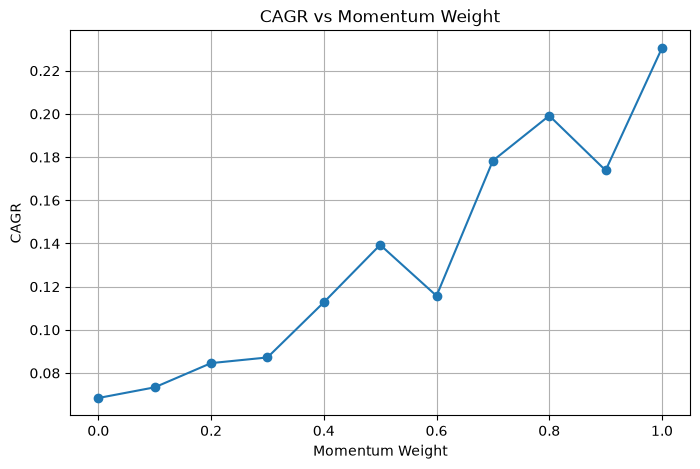

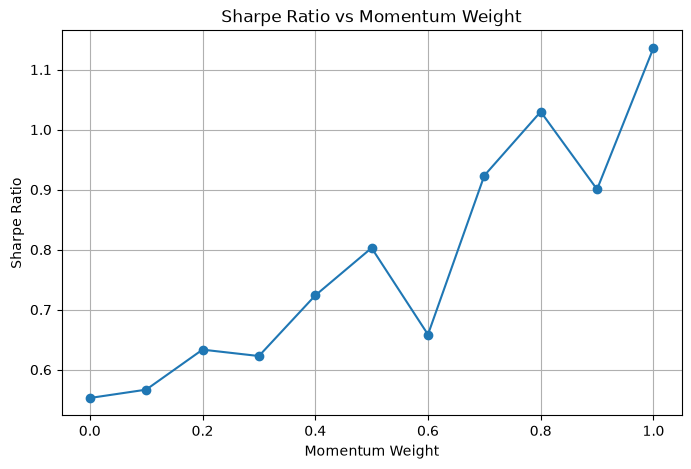

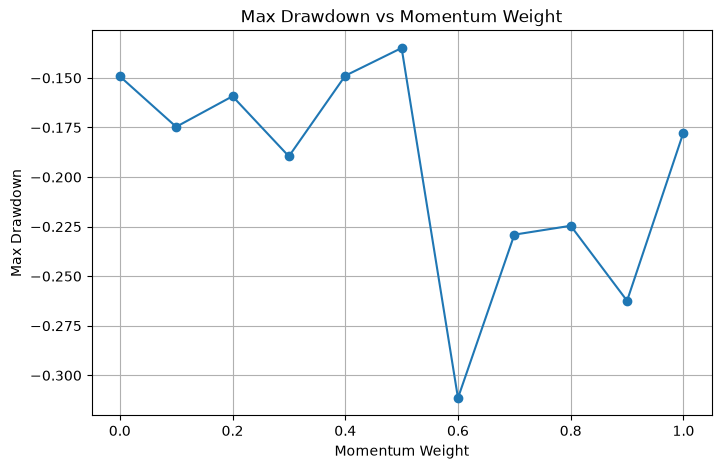

In [14]:
# Plot parameter sensitivity results
plot_parameter_sensitivity(
    results,
    "CAGR"
)
plot_parameter_sensitivity(
    results,
    "Sharpe Ratio"
)
plot_parameter_sensitivity(
    results,
    "Max Drawdown"
)

For the Dow 30 between 2018–2024, adding this definition of low volatility to this momentum strategy reduced risk but did not improve risk-adjusted returns.
